# Monitoreo y data drift

Trabajo de monitoreo del modelo desplegado: lee la tabla que deja el endpoint, la muestrea con una
periodicidad definida y mide si la población cambió de forma que pueda afectar al modelo.

La lógica vive en `model_monitoring.py`. Este notebook la importa y aporta la narrativa y las
visualizaciones, sin duplicar una sola línea de cálculo.

**Tampoco escribe nada.** Lee la línea base, el registro y el informe publicados; puntúa por el
endpoint sin añadir filas al registro, y las figuras van a un directorio temporal. Regenerar los
artefactos es tarea del script:

```bash
python mlops_pipeline/model_monitoring.py
```

## Qué pide la entrega, y dónde se ve

| Pide el enunciado | Dónde se ve |
|---|---|
| Una tabla con los datos pasados al endpoint | 1. La tabla del endpoint |
| Junto con los pronósticos entregados | 1. La tabla del endpoint |
| Con una periodicidad definida, muestrear | 4. La tabla, periodo a periodo |
| Métricas que detecten cambios en la población | 2. Primero, el control y 3. Las cuatro señales |
| Medida del data drift | PSI con el semáforo del sector: 0,10 moderado, 0,25 importante |

In [1]:
import json
import logging
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd()))
import model_monitoring as mo

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)

# El modulo envia el log a la salida; los avisos internos de matplotlib sobran.
logging.getLogger('matplotlib').setLevel(logging.WARNING)

# Este notebook no genera artefactos: si falta uno, se detiene en lugar de
# construirlo. Construirlos es tarea de los scripts.
for ruta in (mo.RUTA_LINEA_BASE, mo.RUTA_REGISTRO, mo.RUTA_INFORME):
    if not ruta.exists():
        raise FileNotFoundError(ruta.name + ': ejecuta model_deploy.py y model_monitoring.py')

# Con la linea base publicada, cargar_linea_base la LEE; no la reconstruye.
base, _ = mo.cargar_linea_base()
p = base['prediccion']

print('Linea base :', base['origen'], '|', base['n'], 'registros | modelo', base['version_modelo'])
print('Mide       :', len(base['variables']), 'variables y', len(base['banderas']), 'banderas')
print('Prediccion : probabilidad media', p['probabilidad_media'],
      '| rechazo previsto', str(p['pct_rechazo']) + '%', '| umbral', p['umbral'])
print('Semaforo   :', base['umbrales_psi'])
print('Periodos   :', mo.NOMBRE_PERIODICIDAD, '|', mo.NOMBRE_PERIODICIDAD_COSECHA)

# Las figuras del modulo se guardan en disco. Aqui van a un directorio temporal
# para no sobrescribir las publicadas en data/models/figuras/monitoreo/.
FIGURAS = Path(tempfile.mkdtemp())

18:56:41 | INFO    | Configuracion cargada desde config.json


Linea base : estratificado_train.csv | 8610 registros | modelo 0b9cf390cc9a
Mide       : 13 variables y 4 banderas
Prediccion : probabilidad media 0.0475 | rechazo previsto 21.25% | umbral 0.0661
Semaforo   : {'moderado': 0.1, 'importante': 0.25}
Periodos   : semanal | mensual por cosecha de desembolso


## 1. La tabla del endpoint

`registro_endpoint.csv` la produce `model_deploy.py` en cada llamada. Cada fila es una decisión: las
13 columnas de entrada **tal como llegaron**, antes de sanear, y lo que el endpoint respondió.

La entrada se guarda cruda a propósito. El saneamiento borra la evidencia de cómo venía la fuente, y
un lote que de pronto llega sin score solo se detecta si el registro conserva el nulo.

In [2]:
registro = mo.cargar_registro()

print(len(registro), 'decisiones | modelo', ', '.join(registro['version_modelo'].unique()))
print('Columnas:', list(registro.columns))

display(registro.groupby('origen').size().rename('decisiones').to_frame())
display(registro['decision'].value_counts().rename('decisiones').to_frame())

# Dos filas por origen: la entrada tal como llego y lo que el endpoint respondio.
entrada = ['fecha_prestamo', 'plazo_meses', 'capital_prestado', 'puntaje_datacredito']
respuesta = ['decision', 'probabilidad_mora', 'puntaje', 'banda', 'motivo']
display(registro.groupby('origen').head(2)[['momento', 'origen'] + entrada + respuesta])

4204 decisiones | modelo 0b9cf390cc9a
Columnas: ['momento', 'origen', 'version_modelo', 'tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'decision', 'probabilidad_mora', 'puntaje', 'banda', 'motivo']


,decisiones
origen,
monitoreo:control (muestra de train),2000
monitoreo:reciente (temporal_test),2154
prueba_de_humo,50


,decisiones
decision,
APROBAR,3228
RECHAZAR,976


,momento,origen,fecha_prestamo,plazo_meses,capital_prestado,puntaje_datacredito,decision,probabilidad_mora,puntaje,banda,motivo
0,2026-09-12 01:34:21+00:00,prueba_de_humo,19/01/2025 13:06,12,5154719,744.0,RECHAZAR,0.112603,573.1,E,puntaje_datacredito -12; promedio_ingresos_datacredito -7; esc_capital_prest...
1,2026-09-12 01:34:21+00:00,prueba_de_humo,13/06/2025 17:27,9,1396562,814.0,APROBAR,0.023424,621.2,B,puntaje_datacredito +9; consultas_por_credito -8; huella_consulta +7
50,2026-09-12 01:34:25+00:00,monitoreo:control (muestra de train),2025-02-08 13:05:00,10,2927668,719.0,RECHAZAR,0.132097,567.9,E,puntaje_datacredito -12; edad_cliente -7; promedio_ingresos_datacredito -6
51,2026-09-12 01:34:25+00:00,monitoreo:control (muestra de train),2025-03-07 11:54:00,6,960000,797.0,RECHAZAR,0.083438,582.7,E,consultas_por_credito -8; promedio_ingresos_datacredito -7; edad_cliente -7
2050,2026-09-12 01:34:26+00:00,monitoreo:reciente (temporal_test),2025-07-12 08:34:00,6,1694845,783.0,APROBAR,0.046164,600.9,D,edad_cliente -7; promedio_ingresos_datacredito +6; discrepancia_ingresos -3
2051,2026-09-12 01:34:26+00:00,monitoreo:reciente (temporal_test),2025-07-12 08:51:00,6,4224000,832.0,APROBAR,0.063176,591.4,D,puntaje_datacredito +9; promedio_ingresos_datacredito -7; huella_consulta -7


**4.204 decisiones, todas del mismo modelo.** 2.000 vienen de la muestra de control, 2.154 de la
cohorte reciente y 50 de la prueba de humo de la Fase 4. El endpoint aprobó 3.228 y rechazó 976.

La columna `version_modelo` es la que hace confiable la medida: si el modelo se cambiara, el
monitoreo sabría qué pronósticos entregó cada versión en lugar de mezclarlos.

## 2. Primero, el control

Medir y anunciar *hay deriva* no prueba nada si la medición nunca se contrastó. Por eso se evalúan
**dos cohortes** contra la línea base:

- **Control:** 2.000 créditos de `estratificado_train`, la misma población del ajuste. Su PSI debe
  quedar cerca de cero. Si no, la medida está rota y el otro número no merece crédito.
- **Reciente:** `temporal_test`, créditos desembolsados desde el 12 de julio de 2025. Es una
  población genuinamente posterior.

Las dos pasan **por el endpoint**, el mismo camino de una solicitud real, y se mide lo que el
endpoint entregó.

,cohorte,n,psi_max,variables_alertadas,psi_prediccion,rechazo_pct,rechazo_previsto_pct,veredicto
0,control (muestra de train),2000,0.0031,0,0.0037,20.90,21.25,SIN CAMBIO RELEVANTE
1,reciente (temporal_test),2154,0.1509,1,0.0166,25.07,21.25,VIGILAR: 1 variables con cambio moderado


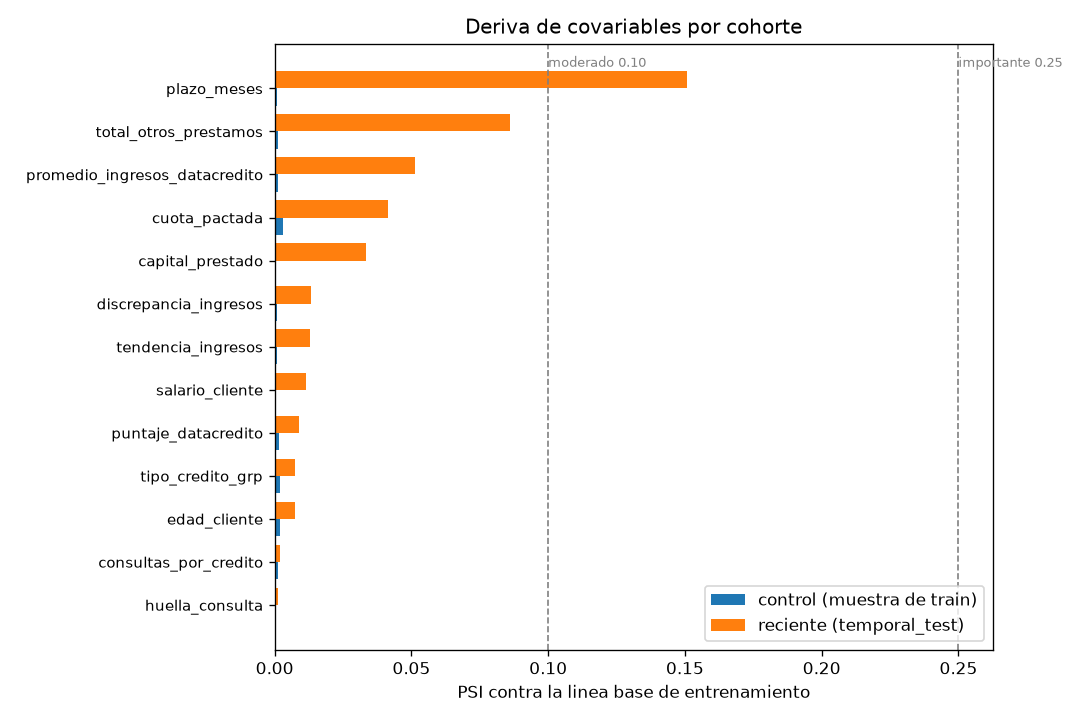

In [3]:
informes = []
for nombre, datos in mo._cohortes_de_contraste().items():
    # Pasa por el endpoint sin escribir: registrar la cohorte la primera vez es
    # tarea del script, y ya consta en el registro.
    probabilidades, _ = mo.puntuar_cohorte(nombre, datos, ya_registrado=True)
    informes.append(mo.evaluar_cohorte(nombre, datos, base, probabilidades))

display(pd.DataFrame([{
    'cohorte': i['cohorte'], 'n': i['n'],
    'psi_max': i['covariables']['psi_maximo'],
    'variables_alertadas': i['covariables']['variables_alertadas'],
    'psi_prediccion': i['prediccion']['psi'],
    'rechazo_pct': i['corte']['pct_rechazo_cohorte'],
    'rechazo_previsto_pct': i['corte']['pct_rechazo_base'],
    'veredicto': i['veredicto'],
} for i in informes]))

# El control y la reciente lado a lado: sin la referencia, una barra de PSI no
# dice si el numero es alto o si asi mide siempre.
display(Image(filename=str(mo.figura_deriva(informes, FIGURAS))))

**La medida discrimina.** El control da un PSI máximo de 0,0031 y rechaza el 20,90% frente al 21,25%
previsto: sobre su propia población, el monitoreo no inventa deriva.

La cohorte reciente llega a **0,1509, casi 50 veces el control**. Sin el control, 0,1509 sería un
número suelto; con él, se sabe que lo que cambió es la población y no la medida.

Veredicto de la reciente: **VIGILAR**. Hay un cambio moderado, no uno que obligue a reentrenar.

## 3. Las cuatro señales en la cohorte reciente

| Señal | Qué mide | Cuándo llega |
|---|---|---|
| Covariables | Distribución de cada entrada, con los cortes de la receta del binning | De inmediato |
| Predicción | Distribución de las probabilidades emitidas | De inmediato, sin esperar la etiqueta |
| Corte | Si el umbral fijo sigue rechazando el volumen previsto | De inmediato |
| Concepto | Relación entre las entradas y el pago real | Tarde: exige que el crédito venza |

Los cortes del PSI **se importan de la receta**, no se recalculan. Así, un PSI alto significa
literalmente que los tramos que el modelo usa se están llenando distinto. El concepto se trata aparte,
en la sección 5.

In [4]:
control, reciente = informes

print('COVARIABLES | PSI contra la linea base')
display(pd.DataFrame(reciente['covariables']['tabla']))

print('PREDICCION')
for clave, valor in reciente['prediccion'].items():
    print('  ' + clave.ljust(26), valor)

print('CORTE')
for clave, valor in reciente['corte'].items():
    print('  ' + clave.ljust(26), valor)

print('BANDERAS | tasa de activacion')
display(pd.DataFrame(reciente['banderas']))

COVARIABLES | PSI contra la linea base


,variable,psi,estado
0,plazo_meses,0.1509,cambio moderado
1,total_otros_prestamos,0.0862,estable
2,promedio_ingresos_datacredito,0.0514,estable
3,cuota_pactada,0.0414,estable
4,capital_prestado,0.0333,estable
5,discrepancia_ingresos,0.0134,estable
6,tendencia_ingresos,0.0129,estable
7,salario_cliente,0.0114,estable
8,puntaje_datacredito,0.0088,estable
9,tipo_credito_grp,0.0076,estable


PREDICCION
  psi                        0.0166
  estado                     estable
  probabilidad_media         0.051377
  probabilidad_media_base    0.0475
  desplazamiento             0.003877
CORTE
  umbral                     0.0661
  pct_rechazo_base           21.25
  pct_rechazo_cohorte        25.07
  desviacion_pp              3.82
  requiere_revision          False
BANDERAS | tasa de activacion


,bandera,tasa_base,tasa_cohorte,casos,razon
0,edad_cliente_corregida,0.0120,0.0149,32,1.24
1,salario_cliente_corregido,0.0217,0.0223,48,1.03
2,tendencia_ingresos_reconstruida,0.0055,0.0046,10,0.85
3,total_otros_prestamos_sospechoso,0.0029,0.0037,8,1.28


**Solo una variable sale de estable: `plazo_meses`, con 0,1509.** Tiene el mayor coeficiente entre las
nueve variables WoE del modelo (0,8573), así que su deriva pesa directamente en la decisión. La
siguiente, `total_otros_prestamos`, se queda en 0,0862.

La **predicción sigue estable** (PSI 0,0166): la probabilidad media sube de 0,0475 a 0,0514. El
**corte** rechaza el 25,07%, 3,82 puntos por encima de lo previsto. No activa la revisión, que exige
una desviación de un tercio (algo más de 7 puntos), pero va en la misma dirección que la deriva.

Las **banderas** se mantienen: ninguna se activa 1,5 veces más que en entrenamiento.
`tendencia_ingresos_reconstruida`, la que suma puntos por una relación que nunca se pudo medir, baja
de 0,55% a 0,46%.

## 4. La tabla, periodo a periodo

El registro se parte en periodos por **dos ejes**, porque responden preguntas distintas:

| Eje | Periodicidad | Pregunta |
|---|---|---|
| Llegada (`momento`) | Semanal | ¿Lo que entra se parece a lo que el modelo aprendió? |
| Cosecha (`fecha_prestamo`) | Mensual | ¿Cambió el riesgo según el mes de desembolso? |

Semanal y no diaria por volumen: un PSI sobre 30 registros es ruido con nombre técnico. En cada
periodo se cuentan **solicitudes distintas**, porque una misma solicitud puntuada dos veces es una
observación, no dos. Un periodo con menos de 100 no se publica, y uno con más de 5.000 se muestrea con
la semilla del proyecto.

In [5]:
ejes = {'llegada': ('momento', mo.PERIODICIDAD),
        'cosecha': ('fecha_prestamo', mo.PERIODICIDAD_COSECHA)}
tamanios, medidos = [], {}

for eje, (columna, frecuencia) in ejes.items():
    medidos[eje] = {}
    for etiqueta, periodo in mo.muestrear(registro, columna, frecuencia).items():
        tamanios.append({'eje': eje, 'periodo': etiqueta,
                         'decisiones': periodo['n_decisiones'],
                         'solicitudes_distintas': periodo['n_solicitudes'],
                         'en_la_muestra': periodo['n_muestra'],
                         'publicable': periodo['suficiente']})
        if not periodo['suficiente']:
            medidos[eje][etiqueta] = {'medible': False}
            continue

        # Un rechazo tecnico no tiene probabilidad: no entra a la medida.
        datos = periodo['datos']
        prob = datos['probabilidad_mora'].to_numpy(dtype=float)
        validas = ~np.isnan(prob)
        resultado = mo.evaluar_cohorte(eje + ' ' + etiqueta, datos.loc[validas],
                                       base, prob[validas])
        medidos[eje][etiqueta] = {**resultado, 'medible': True}

display(pd.DataFrame(tamanios))

,eje,periodo,decisiones,solicitudes_distintas,en_la_muestra,publicable
0,llegada,2026-09-13,4204,3801,3801,True
1,cosecha,2024-11-01,27,27,27,False
2,cosecha,2024-12-01,249,248,248,True
3,cosecha,2025-01-01,377,377,377,True
4,cosecha,2025-02-01,183,181,181,True
5,cosecha,2025-03-01,228,226,226,True
6,cosecha,2025-04-01,181,180,180,True
7,cosecha,2025-05-01,208,208,208,True
8,cosecha,2025-06-01,129,129,129,True
9,cosecha,2025-07-01,537,466,466,True


**El eje de llegada tiene un solo periodo.** El registro se llenó en una sola sesión, así que las
4.204 decisiones caen en la misma semana. En producción ese eje tendría una fila por semana; aquí
demuestra que el muestreo funciona y que el deduplicado actúa: 4.204 decisiones son 3.801 solicitudes
distintas.

**El eje de cosecha sí tiene historia:** 18 meses, de los que 4 quedan bajo el mínimo y no se
publican (noviembre de 2024 y de febrero a abril de 2026). Es preferible un hueco declarado a un
número que nadie puede interpretar.

,eje,periodo,variable_mas_movida,psi_max,psi_prediccion,rechazo_pct,veredicto
0,llegada,2026-09-13,puntaje_datacredito,0.0394,0.0054,22.86,SIN CAMBIO RELEVANTE
1,cosecha,2024-12-01,promedio_ingresos_datacredito,0.2590,0.0246,22.58,REENTRENAR: 1 variables con cambio importante
2,cosecha,2025-01-01,puntaje_datacredito,0.1414,0.0558,15.12,VIGILAR: 3 variables con cambio moderado
3,cosecha,2025-02-01,puntaje_datacredito,0.1429,0.0488,16.02,VIGILAR: 1 variables con cambio moderado
4,cosecha,2025-03-01,puntaje_datacredito,0.1228,0.0315,21.24,VIGILAR: 2 variables con cambio moderado
5,cosecha,2025-04-01,puntaje_datacredito,0.1700,0.0560,22.22,VIGILAR: 2 variables con cambio moderado
6,cosecha,2025-05-01,tipo_credito_grp,0.1455,0.0600,22.60,VIGILAR: 3 variables con cambio moderado
7,cosecha,2025-06-01,tipo_credito_grp,0.2397,0.0671,17.05,VIGILAR: 3 variables con cambio moderado
8,cosecha,2025-07-01,discrepancia_ingresos,0.1353,0.0420,26.39,VIGILAR: 2 variables con cambio moderado
9,cosecha,2025-08-01,plazo_meses,0.2614,0.0157,20.18,REENTRENAR: 1 variables con cambio importante


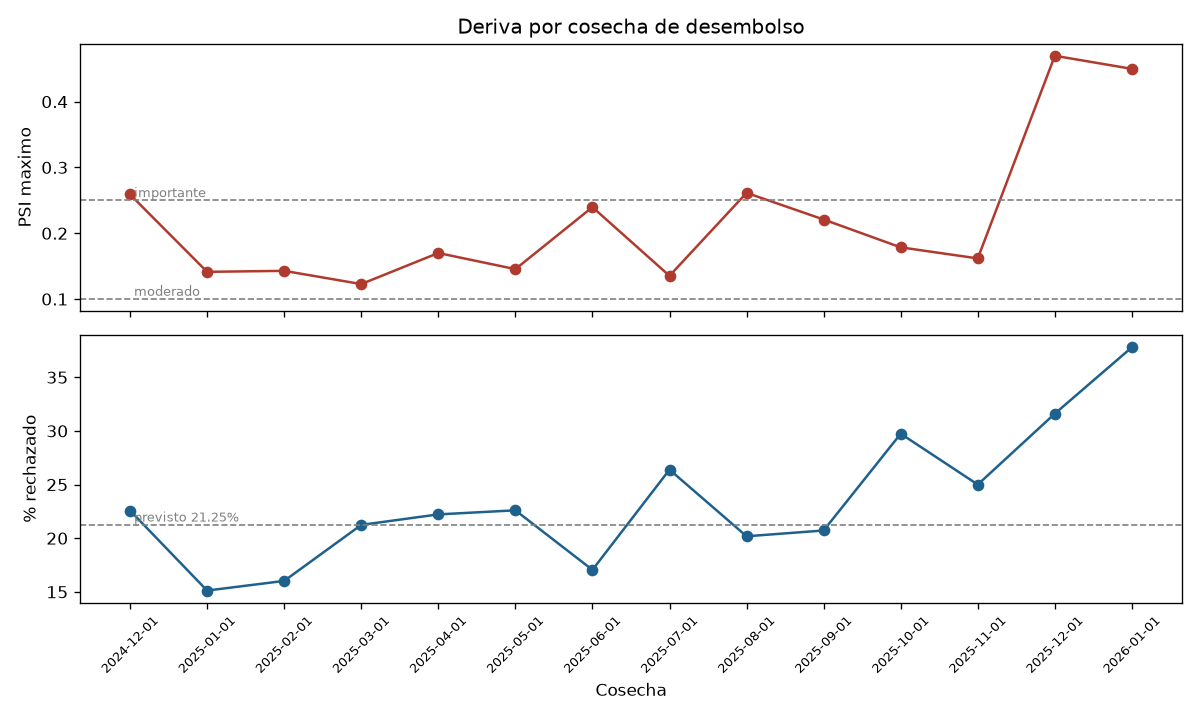

In [6]:
metricas = pd.DataFrame([{
    'eje': eje, 'periodo': etiqueta,
    'variable_mas_movida': r['covariables']['tabla'][0]['variable'],
    'psi_max': r['covariables']['psi_maximo'],
    'psi_prediccion': r['prediccion']['psi'],
    'rechazo_pct': r['corte']['pct_rechazo_cohorte'],
    'veredicto': r['veredicto'],
} for eje, periodos in medidos.items() for etiqueta, r in periodos.items() if r['medible']])
display(metricas)

# PSI maximo y rechazo sobre el mismo eje temporal: si suben juntos, cambiaron
# los clientes; si solo sube el rechazo, fallo el umbral.
display(Image(filename=str(mo.figura_evolucion(medidos['cosecha'], FIGURAS))))

Las 14 cosechas publicables dan **4 REENTRENAR, 1 REVISAR EL CORTE y 9 VIGILAR**. Ninguna sale sin
cambio, y eso obliga a leerlas con cuidado.

**Un mes aislado se desvía por composición.** Hasta junio de 2025 no hay ningún crédito de la cohorte
reciente: solo la muestra de control y unas pocas solicitudes de la prueba de humo. Aun así, esas
cosechas marcan entre 0,12 y 0,26. Con 129 a 377 solicitudes, un mes no reproduce la mezcla completa
del entrenamiento, así que el semáforo por cosecha tiene un piso de ruido más alto que el de una
cohorte grande.

**La señal está en la pendiente.** Desde agosto de 2025, `plazo_meses` encabeza la deriva en cinco de
las seis cosechas y llega a **0,4697 en diciembre y 0,4498 en enero**, casi el doble del máximo de los
meses sin cohorte reciente (0,259). El rechazo pasa del 20,18% en agosto al **37,80% en enero**.
Deriva y rechazo suben juntos: lo que cambió son los clientes, no el umbral.

## 5. Deriva de concepto

Es la única señal que confirma que el modelo se equivoca, y la única que no se puede adelantar. La
cohorte reciente trae la etiqueta, así que se puede medir, pero con una salvedad.

In [7]:
concepto = reciente['concepto']
columnas = ['n', 'moras', 'tasa_mora', 'auc_pr', 'lift_vs_azar', 'ks', 'recall']
grupos = ['cohorte_completa', 'solo_vencidos', 'solo_jovenes']

print('Madurez incompleta en la cohorte reciente:', str(concepto['madurez_incompleta_pct']) + '%')
display(pd.DataFrame([{c: concepto[g][c] for c in columnas} for g in grupos], index=grupos))

for g in grupos[1:]:
    print('  ' + g.ljust(14), 'plazo medio', concepto[g]['plazo_medio'], 'meses')
print('Sesgo de madurez:', concepto['sesgo_de_madurez']['nota'])

Madurez incompleta en la cohorte reciente: 53.4%


,n,moras,tasa_mora,auc_pr,lift_vs_azar,ks,recall
cohorte_completa,2154,69,0.0320,0.0739,2.31,0.2657,0.4203
solo_vencidos,1003,21,0.0209,0.0359,1.71,0.3576,0.2857
solo_jovenes,1151,48,0.0417,0.0968,2.32,0.2807,0.4792


  solo_vencidos  plazo medio 6.0 meses
  solo_jovenes   plazo medio 15.8 meses
Sesgo de madurez: El filtro de madurez selecciona creditos mas cortos, no solo creditos vencidos. Ninguno de los dos subgrupos da una lectura sin sesgo.


**Sobre la cohorte completa, el modelo sigue ordenando el riesgo:** AUC-PR 0,0739 con lift 2,31, es
decir, 2,3 veces mejor que el azar sobre una población que no vio.

**Pero el 53,4% de esos créditos todavía no vence**, y filtrar por madurez no da la lectura limpia
que parece:

| Subgrupo | Créditos | Plazo medio | Mora | Lift |
|---|---|---|---|---|
| Solo vencidos | 1.003 | 6,0 meses | 2,09% | 1,71 |
| Solo jóvenes | 1.151 | 15,8 meses | 4,17% | 2,32 |

Los jóvenes tienen **el doble de mora, no la mitad**. Un crédito sigue vivo justamente porque se
pactó a más meses, y el plazo tiene el mayor coeficiente entre las variables WoE. El filtro de
madurez no aísla el censurado: selecciona créditos cortos. Por eso el concepto se reporta completo y
por subgrupo, con lift, y **no se declara degradación del modelo hasta que la etiqueta madure**.

## 6. El notebook reproduce el informe publicado

Todo lo anterior se calculó en vivo. Si coincide con `monitoreo.json`, el informe que publica el
script corresponde al registro actual y a este análisis.

In [8]:
with open(mo.RUTA_INFORME, encoding='utf-8') as f:
    publicado = json.load(f)


def coincide(calculado, informe):
    return all(calculado[k] == informe[k]
               for k in ('covariables', 'prediccion', 'corte', 'veredicto'))


print('Decisiones: registro', len(registro), '| informe',
      publicado['registro_endpoint']['decisiones'])
for i in informes:
    print('  ' + i['cohorte'].ljust(28), 'coincide:',
          coincide(i, publicado['contraste'][i['cohorte']]))
for eje, periodos in medidos.items():
    iguales = [coincide(r, publicado['por_periodo'][eje]['periodos'][etiqueta])
               for etiqueta, r in periodos.items() if r['medible']]
    print('  eje ' + eje.ljust(24), sum(iguales), 'de', len(iguales), 'periodos coinciden')

Decisiones: registro 4204 | informe 4204
  control (muestra de train)   coincide: True
  reciente (temporal_test)     coincide: True
  eje llegada                  1 de 1 periodos coinciden
  eje cosecha                  14 de 14 periodos coinciden


## Cierre

| Pregunta | Respuesta |
|---|---|
| ¿La medición es fiable? | Sí. El control da PSI 0,0031 sobre su propia población |
| ¿Cambió la población? | Sí, de forma moderada: `plazo_meses` llega a 0,1509 en la cohorte reciente |
| ¿Dónde es más fuerte? | En las cosechas de diciembre de 2025 y enero de 2026, con PSI de 0,47 y 0,45 |
| ¿Afecta a las decisiones? | En volumen, sí: el rechazo sube al 25,07% en la cohorte y al 37,80% en enero |
| ¿Empeoró el modelo? | No se puede afirmar todavía: más de la mitad de la cohorte no ha vencido |

**Qué sigue:** reentrenar sobre datos recientes y volver a fijar el punto de operación, no ajustar el
umbral a mano sobre la población que se quiere medir. La razón es la deriva de la población en la
variable WoE de mayor peso, no una degradación confirmada. Al reentrenar, las cosechas recientes
entran con la salvedad de la sección 5: más de la mitad de sus créditos todavía no ha vencido.